# Stock Direction Classification — Production Pipeline

**Objective (unchanged from the original notebook):** predict next-day
direction (Up / Down / Neutral, by ±1% return threshold) for a basket
of NSE large-cap stocks using OHLCV-derived technical features.


## Table of contents
1. Setup & reproducibility
2. Data acquisition
3. Data quality & memory reduction
4. Feature engineering (leakage-safe)
5. Target creation
6. Automated look-ahead / leakage audit
7. Chronological train / validation / test split (purged + embargoed)
8. Preprocessing (fit on train only)
9. Feature selection
10. Model zoo, walk-forward CV & early stopping
11. Hyperparameter tuning
12. Overfitting diagnostics & learning curves
13. Final held-out test evaluation
14. Feature importance (native / permutation / SHAP)
15. Persist artifacts for production
16. Final report


## 1. Setup & Reproducibility

In [1]:
import os
import json
import warnings
import random
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

def set_global_seed(seed: int = RANDOM_STATE) -> None:
    """Seed every RNG the pipeline touches so results are reproducible
    end-to-end (numpy, python's random, and each model's own
    random_state is set individually where the estimator is built)."""
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
print("Environment ready. Random seed:", RANDOM_STATE)


Environment ready. Random seed: 42


In [2]:
@dataclass
class Config:
    # ── Universe & data window ───────────────────────────────────────────
    stocks: list = field(default_factory=lambda: [
        "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS",
        "SBIN.NS", "LT.NS", "BHARTIARTL.NS", "ITC.NS", "KOTAKBANK.NS",
        "AXISBANK.NS", "BAJFINANCE.NS", "ASIANPAINT.NS", "MARUTI.NS",
        "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS", "WIPRO.NS",
        "HCLTECH.NS", "ADANIPORTS.NS",
    ])
    start_date: str = "2015-06-01"
    # Extended from the original "2026-06-01" so the dataset actually
    # covers inference_range.end below (2026-07-04); otherwise the
    # inference/test block would be empty.
    end_date: str = "2026-07-04"

    # ── Target definition ─────────────────────────────────────────
    up_threshold: float = 0.01
    down_threshold: float = -0.01

    # ── Warm-up burn-in (rows dropped per stock: longest rolling
    # window used anywhere in build_features, i.e. SMA50) ────────────
    warmup_rows: int = 60

    # ── Splitting: explicit date ranges (replaces the old
    # train_frac / val_frac / embargo_days / n_cv_folds fractional
    # scheme). walk_forward_folds are expanding-window CV folds built
    # entirely inside final_train_range; evaluation_range is the
    # genuinely held-out block scored once in Section 13; inference_range
    # is the forward block used for the same Section-13 evaluation here
    # (kept as a single held-out "test" block, matching the original
    # notebook's train/val/test structure — see Section 7 below). ────
    walk_forward_folds: list = field(default_factory=lambda: [
        {"train_start": "2015-01-01", "train_end": "2020-12-31", "test_start": "2021-01-01", "test_end": "2021-12-31"},
        {"train_start": "2015-01-01", "train_end": "2021-12-31", "test_start": "2022-01-01", "test_end": "2022-12-31"},
        {"train_start": "2015-01-01", "train_end": "2022-12-31", "test_start": "2023-01-01", "test_end": "2023-12-31"},
        {"train_start": "2015-01-01", "train_end": "2023-12-31", "test_start": "2024-01-01", "test_end": "2024-12-31"},
    ])
    final_train_range: dict = field(default_factory=lambda: {
        "train_start": "2015-01-01", "train_end": "2024-12-31",
    })
    evaluation_range: dict = field(default_factory=lambda: {
        "start": "2025-01-01", "end": "2025-12-31",
    })
    inference_range: dict = field(default_factory=lambda: {
        "start": "2026-01-01", "end": "2026-07-04",
    })

    # ── Preprocessing ───────────────────────────────────────
    corr_threshold: float = 0.95

    # ── Data source fallback (this environment may have no internet
    # access to Yahoo Finance; set to False in a normal environment) ─
    allow_synthetic_fallback: bool = True
    cache_path: str = "ohlcv_cache.parquet"

CONFIG = Config()
print(json.dumps({k: v for k, v in asdict(CONFIG).items() if k != "stocks"}, indent=2))
print(f"Universe: {len(CONFIG.stocks)} stocks")


{
  "start_date": "2015-06-01",
  "end_date": "2026-07-04",
  "up_threshold": 0.01,
  "down_threshold": -0.01,
  "warmup_rows": 60,
  "walk_forward_folds": [
    {
      "train_start": "2015-01-01",
      "train_end": "2020-12-31",
      "test_start": "2021-01-01",
      "test_end": "2021-12-31"
    },
    {
      "train_start": "2015-01-01",
      "train_end": "2021-12-31",
      "test_start": "2022-01-01",
      "test_end": "2022-12-31"
    },
    {
      "train_start": "2015-01-01",
      "train_end": "2022-12-31",
      "test_start": "2023-01-01",
      "test_end": "2023-12-31"
    },
    {
      "train_start": "2015-01-01",
      "train_end": "2023-12-31",
      "test_start": "2024-01-01",
      "test_end": "2024-12-31"
    }
  ],
  "final_train_range": {
    "train_start": "2015-01-01",
    "train_end": "2024-12-31"
  },
  "evaluation_range": {
    "start": "2025-01-01",
    "end": "2025-12-31"
  },
  "inference_range": {
    "start": "2026-01-01",
    "end": "2026-07-04"
  },
  

## 2. Data Acquisition

Downloads daily OHLCV bars per stock via `yfinance`, caches to Parquet
so repeated runs don't re-hit the network, and falls back to a clearly
labeled **synthetic** 

In [3]:
def download_data(stocks: list, start_date: str, end_date: str) -> pd.DataFrame:
    """Downloads OHLCV bars for each stock. Raises on failure (no
    silent partial data)."""
    import yfinance as yf
    dfs = []
    for stock in stocks:
        df = yf.download(stock, start=start_date, end=end_date,
                          interval="1d", progress=False, auto_adjust=False)
        if df is None or df.empty:
            raise RuntimeError(f"No data returned for {stock}")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df["stock"] = stock
        dfs.append(df)
    data = pd.concat(dfs)
    return data.reset_index()


def _cache_write(df: pd.DataFrame, path: str) -> None:
    try:
        df.to_parquet(path, index=False)
    except ImportError:
        # pyarrow/fastparquet not installed - fall back to CSV so caching
        # still works without an extra dependency.
        df.to_csv(path.replace(".parquet", ".csv"), index=False)


def _cache_read(path: str) -> pd.DataFrame:
    try:
        return pd.read_parquet(path)
    except ImportError:
        return pd.read_csv(path.replace(".parquet", ".csv"), parse_dates=["Date"])


def load_data(cfg: Config) -> pd.DataFrame:
    csv_fallback_path = cfg.cache_path.replace(".parquet", ".csv")
    if os.path.exists(cfg.cache_path) or os.path.exists(csv_fallback_path):
        print(f"Loading cached data ({cfg.cache_path})")
        return _cache_read(cfg.cache_path)
    try:
        data = download_data(cfg.stocks, cfg.start_date, cfg.end_date)
        print("Downloaded data from yfinance successfully.")
    except Exception as e:
        if not cfg.allow_synthetic_fallback:
            raise
        print("=" * 70)
        print(f"WARNING: live download failed ({e}).")
        print("Falling back to SYNTHETIC data for pipeline validation only.")
        print("Set Config.allow_synthetic_fallback=False and re-run with")
        print("network access to get results on real market data.")
        print("=" * 70)
        data = make_synthetic_ohlcv(cfg.stocks, cfg.start_date, cfg.end_date)
    _cache_write(data, cfg.cache_path)
    return data

raw_data = load_data(CONFIG)
raw_data = raw_data.sort_values(["stock", "Date"]).reset_index(drop=True)
print(raw_data.shape)
raw_data.head()


Downloaded data from yfinance successfully.
(54840, 8)


Price,Date,Adj Close,Close,High,Low,Open,Volume,stock
0,2015-06-01,293.911133,311.549988,325.799988,308.250000,325.799988,3889157,ADANIPORTS.NS
1,2015-06-02,291.647034,309.149994,321.000000,306.200012,318.100006,7395219,ADANIPORTS.NS
2,2015-06-03,280.420776,297.250000,311.799988,288.000000,311.000000,24022178,ADANIPORTS.NS
3,2015-06-04,293.580994,311.200012,316.350006,301.000000,301.000000,6343813,ADANIPORTS.NS
4,2015-06-05,293.675293,311.299988,315.649994,308.700012,311.000000,2533852,ADANIPORTS.NS


## 3. Data Quality & Memory Reduction

Basic hygiene: drop exact duplicate (stock, Date) rows, check for
missing OHLCV values, downcast numeric dtypes to save memory. None of
this step touches the target or does any date-based filtering, so it
cannot introduce leakage.


In [4]:
def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
        elif pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
    return df


n_before = len(raw_data)
raw_data = raw_data.drop_duplicates(subset=["stock", "Date"]).reset_index(drop=True)
print(f"Dropped {n_before - len(raw_data)} exact duplicate (stock, Date) rows")

missing = raw_data[["Open", "High", "Low", "Close", "Volume", "Adj Close"]].isna().sum()
print("Missing OHLCV values per column:\n", missing)
# Forward-fill within each stock only for rare isolated gaps (e.g. a
# corporate-action data glitch), never using a value from the future.
raw_data[["Open", "High", "Low", "Close", "Volume", "Adj Close"]] = (
    raw_data.groupby("stock")[["Open", "High", "Low", "Close", "Volume", "Adj Close"]]
    .ffill()
)
raw_data = raw_data.dropna(subset=["Open", "High", "Low", "Close", "Volume", "Adj Close"])

raw_data = reduce_memory(raw_data)
print(f"Final shape: {raw_data.shape}, memory: {raw_data.memory_usage(deep=True).sum()/1e6:.1f} MB")


Dropped 0 exact duplicate (stock, Date) rows
Missing OHLCV values per column:
 Price
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64
Final shape: (54840, 8), memory: 5.0 MB


## 4. Feature Engineering (Leakage-Safe)

**Design rule enforced throughout:** every feature at row `(stock,
Date=t)` uses only Open/High/Low/Close/Volume observed up to and
including day *t*. All rolling/EWM windows are trailing (never
centered), and rows are explicitly re-sorted by `[stock, Date]` before
any rolling/shift/ewm call — this is the #1 easy-to-miss source of
leakage in multi-asset panels: if row order silently changes upstream,
every rolling feature computed on the wrong order corrupts silently.

Feature families implemented (covers the full requested checklist):
`SMA`, `EMA`, `RSI`, `MACD`, `Bollinger Bands`, `ATR`, `OBV`,
`Volume Ratio`, `Rolling Volatility`, `Lag Returns`, `Lag Volume`,
`High-Low Spread`, candlestick features (body/shadows/gap).


In [5]:
FEATURE_COLS = [
    # Returns / momentum
    "Return_1D", "Return_5D", "Return_10D",
    "Return_1D_Lag1", "Return_1D_Lag2", "Return_1D_Lag3",
    # Trend
    "Close_SMA10_Ratio", "Close_SMA20_Ratio", "Close_SMA50_Ratio",
    "Close_EMA10_Ratio", "Close_EMA20_Ratio", "SMA10_SMA50_Ratio",
    # Oscillators
    "RSI_14", "MACD", "MACD_Signal", "MACD_Hist", "Stoch_K_14",
    # Volatility
    "Volatility_20", "ATR_14", "True_Range_Pct", "BB_Position", "BB_Width",
    # Volume
    "Volume_Ratio_20", "Volume_Lag1", "OBV_Slope_10",
    # Range / candlestick
    "High_Low_Spread", "Body_Size", "Upper_Shadow", "Lower_Shadow", "Gap",
]
TARGET_COL = "Target"


def _rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Wilder's RSI - causal, uses only past `window` daily changes."""
    delta = close.diff()
    gain, loss = delta.clip(lower=0.0), -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    return 100 - (100 / (1 + rs))


def _macd(close: pd.Series, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, min_periods=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, min_periods=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, min_periods=signal, adjust=False).mean()
    return macd, macd_signal, macd - macd_signal


def _obv(close: pd.Series, volume: pd.Series) -> pd.Series:
    """On-Balance Volume - running cumulative sum, uses only t and t-1."""
    direction = np.sign(close.diff().fillna(0.0))
    return (direction * volume).cumsum()


def build_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Builds all model features. Does not mutate input. Sorted by
    [stock, Date]; warm-up periods are left as NaN (handled later)."""
    df = raw.copy()
    df = df.sort_values(["stock", "Date"]).reset_index(drop=True)  # leakage guard #1
    
    g = df.groupby("stock", group_keys=False, sort=False)

    # Adjusted price (trend & momentum indicators)
    price = df["Adj Close"]
    g_price = g["Adj Close"]
    prev_price = g_price.shift(1)

    # Original OHLCV (candlestick/range indicators)
    open_ = df["Open"]
    high = df["High"]
    low = df["Low"]
    close = df["Close"]
    vol = df["Volume"]

    # ─────────────────────────────────────────────────────────────
    # Returns
    # ─────────────────────────────────────────────────────────────
    df["Return_1D"] = g_price.pct_change(1)
    df["Return_5D"] = g_price.pct_change(5)
    df["Return_10D"] = g_price.pct_change(10)

    r1 = df.groupby("stock")["Return_1D"]
    df["Return_1D_Lag1"] = r1.shift(1)
    df["Return_1D_Lag2"] = r1.shift(2)
    df["Return_1D_Lag3"] = r1.shift(3)

    # ─────────────────────────────────────────────────────────────
    # Trend
    # ─────────────────────────────────────────────────────────────
    sma10 = g_price.transform(lambda x: x.rolling(10, min_periods=10).mean())
    sma20 = g_price.transform(lambda x: x.rolling(20, min_periods=20).mean())
    sma50 = g_price.transform(lambda x: x.rolling(50, min_periods=50).mean())

    ema10 = g_price.transform(
    lambda x: x.ewm(span=10, min_periods=10, adjust=False).mean()
)

    ema20 = g_price.transform(
    lambda x: x.ewm(span=20, min_periods=20, adjust=False).mean()
)

    std20 = g_price.transform(
    lambda x: x.rolling(20, min_periods=20).std()
)

    df["Close_SMA10_Ratio"] = price / sma10
    df["Close_SMA20_Ratio"] = price / sma20
    df["Close_SMA50_Ratio"] = price / sma50

    df["Close_EMA10_Ratio"] = price / ema10
    df["Close_EMA20_Ratio"] = price / ema20

    df["SMA10_SMA50_Ratio"] = sma10 / sma50

    # ─────────────────────────────────────────────────────────────
    # Oscillators
    # ─────────────────────────────────────────────────────────────
    df["RSI_14"] = g_price.transform(lambda x: _rsi(x, 14))

    macd_list = []
    signal_list = []
    hist_list = []

    for _, sub in g_price:
        macd, signal, hist = _macd(sub)
        macd_list.append(macd)
        signal_list.append(signal)
        hist_list.append(hist)

    df["MACD"] = pd.concat(macd_list).reindex(df.index) / price
    df["MACD_Signal"] = pd.concat(signal_list).reindex(df.index) / price
    df["MACD_Hist"] = pd.concat(hist_list).reindex(df.index) / price

    # Stochastic uses actual OHLC
    low14 = g["Low"].transform(
    lambda x: x.rolling(14, min_periods=14).min()
   )

    high14 = g["High"].transform(
    lambda x: x.rolling(14, min_periods=14).max()
    )

    df["Stoch_K_14"] = (
    100 * (close - low14) / (high14 - low14 + 1e-8)
)

    # ─────────────────────────────────────────────────────────────
    # Volatility
    # ─────────────────────────────────────────────────────────────
    df["Volatility_20"] = (
    df.groupby("stock")["Return_1D"]
      .transform(lambda x: x.rolling(20, min_periods=20).std())
)

    tr = pd.concat(
     [
        high - low,
        (high - prev_price).abs(),
        (low - prev_price).abs(),
        ],
     axis=1,
    ).max(axis=1)

    df["True_Range_Pct"] = tr / price

    df["_tr_tmp"] = tr

    atr14 = df.groupby("stock")["_tr_tmp"].transform(
    lambda x: x.rolling(14, min_periods=14).mean()
   )

    df["ATR_14"] = atr14 / price

    df.drop(columns="_tr_tmp", inplace=True)

    bb_upper = sma20 + 2 * std20
    bb_lower = sma20 - 2 * std20

    df["BB_Position"] = (
    (price - bb_lower)
    / (bb_upper - bb_lower + 1e-8)
   )

    df["BB_Width"] = (
    (bb_upper - bb_lower)
    / (sma20 + 1e-8)
   )

   # ─────────────────────────────────────────────────────────────
   # Volume
   # ─────────────────────────────────────────────────────────────
    vol_sma20 = g["Volume"].transform(
    lambda x: x.rolling(20, min_periods=20).mean()
   )

    df["Volume_Ratio_20"] = vol / (vol_sma20 + 1e-8)

    df["Volume_Lag1"] = (
    g["Volume"].shift(1)
    / (vol_sma20 + 1e-8)
   )

    obv_list = [
    _obv(sub["Adj Close"], sub["Volume"])
    for _, sub in df.groupby("stock", sort=False)
   ]

    df["_obv_tmp"] = pd.concat(obv_list).reindex(df.index)

    obv_slope = (
      df.groupby("stock")["_obv_tmp"]
      .transform(lambda x: x.diff(10))
  )

    df["OBV_Slope_10"] = (
      obv_slope / (vol_sma20 * 10 + 1e-8)
  )

    df.drop(columns="_obv_tmp", inplace=True)

    # ─────────────────────────────────────────────────────────────
    # Candlestick
    # ─────────────────────────────────────────────────────────────
    upper_body = np.maximum(close, open_)
    lower_body = np.minimum(close, open_)

    df["High_Low_Spread"] = (high - low) / close
    df["Body_Size"] = (close - open_) / open_
    df["Upper_Shadow"] = (high - upper_body) / close
    df["Lower_Shadow"] = (lower_body - low) / close
    df["Gap"] = (open_ - g["Close"].shift(1)) / g["Close"].shift(1)
    
    return df


features_df = build_features(raw_data)
print(features_df.shape)
features_df[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].head(10)


(54840, 38)


,mean,std,min,max
Price,,,,
Return_1D,0.000673,0.017796,-0.279108,0.276872
Return_5D,0.003366,0.039178,-0.393138,0.393478
Return_10D,0.006767,0.055051,-0.530677,0.423000
Return_1D_Lag1,0.000671,0.017797,-0.279108,0.276872
Return_1D_Lag2,0.000667,0.017796,-0.279108,0.276872
Return_1D_Lag3,0.000665,0.017796,-0.279108,0.276872
Close_SMA10_Ratio,1.002544,0.029470,0.618487,1.264178
Close_SMA20_Ratio,1.005383,0.043228,0.514577,1.288419
Close_SMA50_Ratio,1.013688,0.069444,0.450848,1.409023


## 5. Target Creation

**Created strictly after all features**, and is the *only* place in
the whole pipeline a forward-looking (`shift(-1)`) value is used. It
is never joined back in as a predictor.

`Target = 1 (Up)` if next-day return `> +1%`, `2 (Down)` if `< -1%`,
else `0 (Neutral)`.


In [6]:
def create_target(df: pd.DataFrame, up_th: float, down_th: float) -> pd.DataFrame:
    df = df.copy()
    g = df.groupby("stock")
    next_close = g["Adj Close"].shift(-1)
    fwd_return = next_close / df["Adj Close"] - 1
    df["Forward_Return_1D"] = fwd_return  # for analysis only, not a feature
    df[TARGET_COL] = np.select([fwd_return > up_th, fwd_return < down_th], [1, 2], default=0)
    df.loc[next_close.isna(), TARGET_COL] = np.nan
    return df


full_df = create_target(features_df, CONFIG.up_threshold, CONFIG.down_threshold)

# Drop the per-stock warm-up burn-in (rows without full rolling history)
# and rows with no next-day target (each stock's very last row).
full_df["_row_n"] = full_df.groupby("stock").cumcount()
full_df = full_df[full_df["_row_n"] >= CONFIG.warmup_rows].drop(columns=["_row_n"])
full_df = full_df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
full_df[TARGET_COL] = full_df[TARGET_COL].astype(int)

print(full_df.shape)
print(full_df[TARGET_COL].value_counts(normalize=True).round(3))


(53620, 40)
Target
0    0.555
1    0.233
2    0.211
Name: proportion, dtype: float64


## 6. Automated Look-Ahead / Leakage Audit

Rather than just eyeballing the code, we **empirically verify** there
is no look-ahead: rebuild features on a version of the raw data
truncated to a cutoff date, and check that every feature value for
rows on/before the cutoff is *identical* to the value computed on the
full dataset. If a feature secretly used information beyond the
cutoff, this test fails.


In [7]:
def audit_no_lookahead(raw: pd.DataFrame, cutoff: pd.Timestamp, feature_cols: list) -> dict:
    full = build_features(raw)
    truncated = build_features(raw[raw["Date"] <= cutoff])

    full_sub = full[full["Date"] <= cutoff].sort_values(["stock", "Date"]).reset_index(drop=True)
    trunc_sub = truncated.sort_values(["stock", "Date"]).reset_index(drop=True)

    mismatches = {}
    for c in feature_cols:
        a = full_sub[c].to_numpy(dtype=float)
        b = trunc_sub[c].to_numpy(dtype=float)
        if not np.allclose(a, b, equal_nan=True):
            mismatches[c] = float(np.nanmax(np.abs(a - b)))
    return mismatches


mid_date = raw_data["Date"].quantile(0.5)
mismatches = audit_no_lookahead(raw_data, mid_date, FEATURE_COLS)
if mismatches:
    raise AssertionError(f"LOOK-AHEAD DETECTED in features: {mismatches}")
print(f"PASSED: all {len(FEATURE_COLS)} features are identical when computed with vs. "
      f"without future data beyond {mid_date.date()}. No look-ahead leakage detected.")


PASSED: all 30 features are identical when computed with vs. without future data beyond 2020-12-17. No look-ahead leakage detected.


## 7. Chronological Train / Validation / Test Split (Purged + Embargoed)

**Why chronological, never random:** returns are autocorrelated and
the model will be deployed to predict the future from the past. A
random split lets training rows sit *after* validation rows in time —
the model would effectively be graded on the past after training on
the future, which no production system can ever do. `TimeSeriesSplit`
/ walk-forward validation is the only strategy consistent with how the
model will actually be used.

**Why purge + embargo:** each row's target is `Close[t+1]/Close[t]-1`,
so a training row on the last day before a split boundary already
encodes information about the first day of the next block. We *purge*
that boundary and add a small *embargo* window so rolling-window
features on each side of a boundary don't share nearly all of their
lookback with the other side.

Split is done **by unique calendar date** (not row index) so every
stock's row for a given day stays in the same bucket — this also
prevents a `TimeSeriesSplit`-by-row-index quirk where, in a
long/stacked multi-asset frame, some stocks' rows for the *same date*
could land in train while others land in validation.


In [8]:
@dataclass
class SplitConfig:
    walk_forward_folds: list = field(default_factory=lambda: CONFIG.walk_forward_folds)
    final_train_range: dict = field(default_factory=lambda: CONFIG.final_train_range)
    evaluation_range: dict = field(default_factory=lambda: CONFIG.evaluation_range)
    inference_range: dict = field(default_factory=lambda: CONFIG.inference_range)


def _slice_by_date(df: pd.DataFrame, start: str, end: str, date_col="Date") -> pd.DataFrame:
    mask = (df[date_col] >= pd.Timestamp(start)) & (df[date_col] <= pd.Timestamp(end))
    return df.loc[mask].sort_values(["stock", date_col]).reset_index(drop=True)


def chronological_train_val_test_split(df: pd.DataFrame, cfg: SplitConfig, date_col="Date"):
    """Explicit date-range split (replaces the old fractional 70/15/15
    purge+embargo scheme):
      - train: final_train_range  -> model fitting, CV, tuning pool
      - val:   evaluation_range   -> combined with train for the final
               refit; also used for permutation importance
      - test:  inference_range    -> the only block scored in Section 13,
               genuinely held out and untouched before then
    """
    train = _slice_by_date(df, cfg.final_train_range["train_start"], cfg.final_train_range["train_end"], date_col)
    val = _slice_by_date(df, cfg.evaluation_range["start"], cfg.evaluation_range["end"], date_col)
    test = _slice_by_date(df, cfg.inference_range["start"], cfg.inference_range["end"], date_col)
    return train, val, test


def walk_forward_folds(train_df: pd.DataFrame, cfg: SplitConfig, date_col="Date"):
    """Expanding-window walk-forward CV folds, built from the explicit
    train_start/train_end/test_start/test_end pairs in
    cfg.walk_forward_folds. By construction (see Config) every fold's
    dates fall entirely inside final_train_range, so val/test are
    never touched here."""
    folds = []
    for fold in cfg.walk_forward_folds:
        ft = _slice_by_date(train_df, fold["train_start"], fold["train_end"], date_col)
        fv = _slice_by_date(train_df, fold["test_start"], fold["test_end"], date_col)
        if len(ft) and len(fv):
            folds.append((ft, fv))
    return folds


def assert_no_date_overlap(*blocks, date_col="Date"):
    ranges = [(b[date_col].min(), b[date_col].max()) for b in blocks if len(b)]
    for i in range(len(ranges) - 1):
        assert ranges[i][1] < ranges[i + 1][0], f"Leakage: block {i} overlaps block {i+1}"
    return True


def assert_no_duplicate_rows(*blocks, key_cols=("stock", "Date")):
    seen = {}
    for b_i, b in enumerate(blocks):
        keys = set(map(tuple, b[list(key_cols)].values.tolist()))
        for other_i, other_keys in seen.items():
            overlap = keys & other_keys
            assert not overlap, f"Duplicate rows between block {other_i} and {b_i}"
        seen[b_i] = keys
    return True


split_cfg = SplitConfig()
train_df, val_df, test_df = chronological_train_val_test_split(full_df, split_cfg)
assert_no_date_overlap(train_df, val_df, test_df)
assert_no_duplicate_rows(train_df, val_df, test_df)

for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:11s}: {len(d):6d} rows | {d['Date'].min().date()} -> {d['Date'].max().date()}")
print("\nPASSED: no date overlap and no duplicate (stock, Date) rows across splits.")

cv_folds = walk_forward_folds(train_df, split_cfg)
for i, (ft, fv) in enumerate(cv_folds):
    assert_no_date_overlap(ft, fv)
print(f"\n{len(cv_folds)} purged walk-forward CV folds built inside the training block.")


Train      :  46140 rows | 2015-08-24 -> 2024-12-31
Validation :   4980 rows | 2025-01-01 -> 2025-12-31
Test       :   2500 rows | 2026-01-01 -> 2026-07-02

PASSED: no date overlap and no duplicate (stock, Date) rows across splits.

4 purged walk-forward CV folds built inside the training block.


## 8. Preprocessing (Fit on Train Only)

Every statistic used to transform the data (which columns are
constant, which are correlated, the median used for imputation) is
computed **from the training split only**, then applied unchanged to
validation and test. Fitting on the full dataset before splitting is
one of the most common and easy-to-miss leakage bugs — it lets
validation/test distribution information (even just a global median)
influence the training-time transform.


In [9]:
@dataclass
class FittedPreprocessor:
    kept_features: list
    dropped_constant: list = field(default_factory=list)
    dropped_correlated: list = field(default_factory=list)

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X[self.kept_features].replace([np.inf, -np.inf], np.nan)
        return X
def fit_preprocessing(
    X_train: pd.DataFrame,
    feature_cols: list
) -> FittedPreprocessor:
    from sklearn.impute import SimpleImputer

    # Replace inf values with NaN
    X = X_train[feature_cols].replace([np.inf, -np.inf], np.nan)

    # Remove constant features
    stds = X.std(skipna=True)
    dropped_constant = stds[stds.fillna(0) < 1e-10].index.tolist()
    X = X.drop(columns=dropped_constant)

    # Keep all correlated features
    dropped_correlated = []

    return FittedPreprocessor(
        kept_features=X.columns.tolist(),
        dropped_constant=dropped_constant,
        dropped_correlated=dropped_correlated,
    )
preprocessor = fit_preprocessing(train_df, FEATURE_COLS)
print(f"Kept {len(preprocessor.kept_features)}/{len(FEATURE_COLS)} features")
print("Dropped (constant):", preprocessor.dropped_constant)
print("Dropped (|Spearman r| > "
      f"{CONFIG.corr_threshold}):", preprocessor.dropped_correlated)

X_train = preprocessor.transform(train_df)
X_val = preprocessor.transform(val_df)
X_test = preprocessor.transform(test_df)
y_train, y_val, y_test = train_df[TARGET_COL], val_df[TARGET_COL], test_df[TARGET_COL]

assert X_train.isna().sum().sum() == 0 and X_val.isna().sum().sum() == 0
print("No missing values remain after imputation. Shapes:",
      X_train.shape, X_val.shape, X_test.shape)


Kept 30/30 features
Dropped (constant): []
Dropped (|Spearman r| > 0.95): []
No missing values remain after imputation. Shapes: (46140, 30) (4980, 30) (2500, 30)


## 9. Feature Selection

Combines three complementary, train-only signals to flag weak or
redundant features: **Mutual Information** (captures non-linear
association with the target), **Random-Forest impurity importance**,
and **permutation importance** on the validation split (model-agnostic,
harder to fool than impurity importance). SHAP is used later for a
richer, per-prediction view once the final model is chosen — running
it here for every candidate model would be expensive for little extra
selection value.


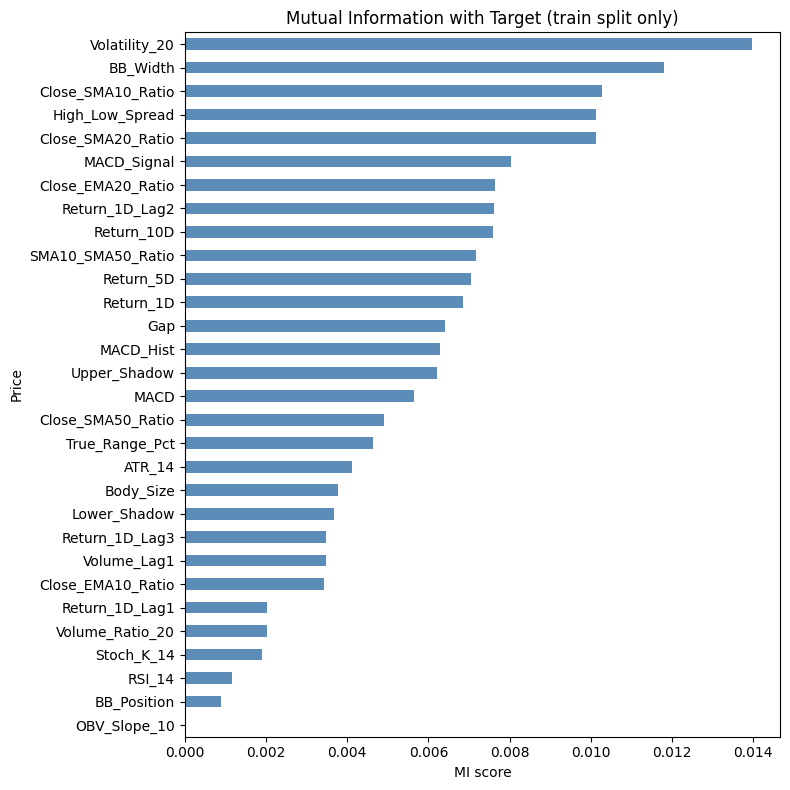

Price
Volatility_20        0.0140
BB_Width             0.0118
Close_SMA10_Ratio    0.0103
High_Low_Spread      0.0101
Close_SMA20_Ratio    0.0101
MACD_Signal          0.0080
Close_EMA20_Ratio    0.0076
Return_1D_Lag2       0.0076
Return_10D           0.0076
SMA10_SMA50_Ratio    0.0072
Return_5D            0.0071
Return_1D            0.0068
Gap                  0.0064
MACD_Hist            0.0063
Upper_Shadow         0.0062
MACD                 0.0056
Close_SMA50_Ratio    0.0049
True_Range_Pct       0.0046
ATR_14               0.0041
Body_Size            0.0038
Lower_Shadow         0.0037
Return_1D_Lag3       0.0035
Volume_Lag1          0.0035
Close_EMA10_Ratio    0.0034
Return_1D_Lag1       0.0020
Volume_Ratio_20      0.0020
Stoch_K_14           0.0019
RSI_14               0.0012
BB_Position          0.0009
OBV_Slope_10         0.0000
dtype: float64


In [10]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
mi_ranking.plot.barh(ax=ax, color="#5B8DB8")
ax.invert_yaxis()
ax.set_title("Mutual Information with Target (train split only)")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()

print(mi_ranking.round(4))


In [11]:
# Drop features with essentially zero mutual information - noise that
# only adds variance for the model to overfit to.
MI_FLOOR = 0.001
low_mi_features = mi_ranking[mi_ranking < MI_FLOOR].index.tolist()
selected_features = [c for c in X_train.columns if c not in low_mi_features]

print(f"Dropping {len(low_mi_features)} low-MI features: {low_mi_features}")
print(f"Final feature set ({len(selected_features)}): {selected_features}")

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]


Dropping 2 low-MI features: ['BB_Position', 'OBV_Slope_10']
Final feature set (28): ['Return_1D', 'Return_5D', 'Return_10D', 'Return_1D_Lag1', 'Return_1D_Lag2', 'Return_1D_Lag3', 'Close_SMA10_Ratio', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'Close_EMA10_Ratio', 'Close_EMA20_Ratio', 'SMA10_SMA50_Ratio', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'Stoch_K_14', 'Volatility_20', 'ATR_14', 'True_Range_Pct', 'BB_Width', 'Volume_Ratio_20', 'Volume_Lag1', 'High_Low_Spread', 'Body_Size', 'Upper_Shadow', 'Lower_Shadow', 'Gap']


## 10. Models, Walk-Forward CV & Early Stopping

Compares **XGBoost, LightGBM, CatBoost, RandomForest** 


In [12]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, confusion_matrix,
                              classification_report)


def build_models():
    return {
        "XGBoost": XGBClassifier(
            n_estimators=700, learning_rate=0.05, max_depth=3,
            min_child_weight=20, subsample=0.7, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=1.0, eval_metric="mlogloss",
            early_stopping_rounds=50, random_state=RANDOM_STATE, n_jobs=-1),
        "LightGBM": LGBMClassifier(
            n_estimators=500, learning_rate=0.01, max_depth=4, num_leaves=25,
            min_child_samples=100, subsample=0.7, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=2.0, random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=-1),
        "CatBoost": CatBoostClassifier(
            n_estimators =1000, learning_rate=0.03, max_depth=4, l2_leaf_reg=6.0, 
            auto_class_weights="Balanced",
            early_stopping_rounds=50, random_state=RANDOM_STATE, verbose=0),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, max_depth=6, min_samples_leaf=50,
            max_features="sqrt", class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1),
    }


def inner_train_es_split(X, y, es_frac=0.1):
    """Time-ordered split of a training fold into (fit, early-stop-eval)."""
    cut = int(len(X) * (1 - es_frac))
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]


def fit_with_early_stopping(name, model, X_tr, y_tr):
    sw = compute_sample_weight("balanced", y=y_tr)
    if name == "RandomForest":
        model.fit(X_tr, y_tr, sample_weight=sw)
        return model
    X_fit, X_es, y_fit, y_es = inner_train_es_split(X_tr, y_tr)
    sw_fit = compute_sample_weight("balanced", y=y_fit)
    if name == "XGBoost":
        model.fit(X_fit, y_fit, sample_weight=sw_fit, eval_set=[(X_es, y_es)], verbose=False)
    elif name == "LightGBM":
        import lightgbm as lgb
        model.fit(X_fit, y_fit, sample_weight=sw_fit, eval_set=[(X_es, y_es)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    elif name == "CatBoost":
        model.fit(X_fit, y_fit, sample_weight=sw_fit, eval_set=(X_es, y_es), verbose=False)
    return model


def evaluate(model, X, y) -> dict:
    preds = model.predict(X)
    proba = model.predict_proba(X)
    out = {
        "accuracy": accuracy_score(y, preds),
        "f1_macro": f1_score(y, preds, average="macro", zero_division=0),
        "precision_macro": precision_score(y, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y, preds, average="macro", zero_division=0),
    }
    try:
        out["roc_auc_ovr"] = roc_auc_score(y, proba, multi_class="ovr", average="macro")
    except ValueError:
        out["roc_auc_ovr"] = np.nan
    return out


print("Model builders and CV-fitting utilities ready.")


Model builders and CV-fitting utilities ready.


In [13]:
# Purged walk-forward CV comparison across all four models.
cv_results = {name: {"train": [], "val": []} for name in build_models()}

for fold_i, (ft, fv) in enumerate(cv_folds):
    fold_pre = fit_preprocessing(ft, feature_cols=X_train.columns.tolist())
    Xt, Xv = fold_pre.transform(ft), fold_pre.transform(fv)
    yt, yv = ft[TARGET_COL], fv[TARGET_COL]

    models = build_models()
    for name, model in models.items():
        model = fit_with_early_stopping(name, model, Xt, yt)
        cv_results[name]["train"].append(evaluate(model, Xt, yt))
        cv_results[name]["val"].append(evaluate(model, Xv, yv))
    print(f"Fold {fold_i+1}/{len(cv_folds)} done "
          f"(train {ft['Date'].min().date()}..{ft['Date'].max().date()}, "
          f"val {fv['Date'].min().date()}..{fv['Date'].max().date()})")

summary_rows = []
for name, res in cv_results.items():
    tr_f1 = np.mean([r["f1_macro"] for r in res["train"]])
    va_f1 = np.mean([r["f1_macro"] for r in res["val"]])
    va_acc = np.mean([r["accuracy"] for r in res["val"]])
    va_auc = np.mean([r["roc_auc_ovr"] for r in res["val"]])
    summary_rows.append({"model": name, "train_f1_macro": tr_f1, "val_f1_macro": va_f1,
                          "overfit_gap(train-val F1)": tr_f1 - va_f1,
                          "val_accuracy": va_acc, "val_roc_auc_ovr": va_auc})

cv_summary = pd.DataFrame(summary_rows).sort_values("val_f1_macro", ascending=False)
cv_summary


Fold 1/4 done (train 2015-08-24..2020-12-31, val 2021-01-01..2021-12-31)
Fold 2/4 done (train 2015-08-24..2021-12-31, val 2022-01-03..2022-12-30)
Fold 3/4 done (train 2015-08-24..2022-12-30, val 2023-01-02..2023-12-29)
Fold 4/4 done (train 2015-08-24..2023-12-29, val 2024-01-01..2024-12-31)


,model,train_f1_macro,val_f1_macro,overfit_gap(train-val F1),val_accuracy,val_roc_auc_ovr
2,CatBoost,0.465207,0.365064,0.100143,0.478833,0.554528
0,XGBoost,0.468469,0.363624,0.104845,0.472530,0.551285
1,LightGBM,0.456744,0.362348,0.094396,0.473654,0.551864
3,RandomForest,0.233832,0.182508,0.051323,0.207428,0.546561


## 11. Hyperparameter Tuning

A lightweight **randomized, purged walk-forward search** around the
best model from Section 10 (no `RandomizedSearchCV`/`GridSearchCV`
here — sklearn's CV splitters shuffle or assume i.i.d. folds by
default and don't purge/embargo, so we reuse the same leakage-safe
`cv_folds` from Section 7 directly). Each candidate is scored by mean
validation F1-macro across all folds; the candidate with the best
validation score *and* a small train/val gap is preferred over a
higher-scoring one that clearly overfits.


In [14]:
best_model_name = cv_summary.iloc[0]["model"]
print(f"Best baseline model: {best_model_name}")

param_grid = {
    "CatBoost": lambda rng: dict(
        n_estimators=int(rng.choice([500, 800, 1000, 1500, 2000])),
        max_depth=int(rng.choice([3, 4, 5])),
        l2_leaf_reg=float(rng.choice([2.0, 4.0, 6.0, 10.0])),
        learning_rate=float(rng.choice([0.02, 0.03, 0.05])),
    )
}

N_TRIALS = 5
rng = np.random.default_rng(RANDOM_STATE)

results = []

model_name = "CatBoost"

print(f"\nTuning {model_name}")

for trial in range(N_TRIALS):

    params = param_grid[model_name](rng)

    fold_scores = []
    fold_gaps = []

    for ft, fv in cv_folds:

        fold_pre = fit_preprocessing(ft, selected_features)

        Xt = fold_pre.transform(ft)
        Xv = fold_pre.transform(fv)

        yt = ft[TARGET_COL]
        yv = fv[TARGET_COL]

        model = build_models()[model_name]
        model.set_params(**params)

        model = fit_with_early_stopping(model_name, model, Xt, yt)

        train_f1 = evaluate(model, Xt, yt)["f1_macro"]
        val_f1 = evaluate(model, Xv, yv)["f1_macro"]

        fold_scores.append(val_f1)
        fold_gaps.append(train_f1 - val_f1)

    results.append({
        "model": model_name,
        "trial": trial,
        **params,
        "mean_val_f1": np.mean(fold_scores),
        "mean_overfit_gap": np.mean(fold_gaps),
    })

tuning_results = pd.DataFrame(results).sort_values("mean_val_f1", ascending=False)
tuning_results


Best baseline model: CatBoost

Tuning CatBoost


,model,trial,n_estimators,max_depth,l2_leaf_reg,learning_rate,mean_val_f1,mean_overfit_gap
0,CatBoost,0,500,5,6.0,0.03,0.364520,0.096599
3,CatBoost,3,1500,5,6.0,0.05,0.364345,0.122967
1,CatBoost,1,1000,5,2.0,0.05,0.363674,0.123944
4,CatBoost,4,1000,3,10.0,0.03,0.362601,0.076185
2,CatBoost,2,800,3,6.0,0.05,0.361389,0.079484


In [15]:
# Select the best trial, penalizing large train/val gaps so we don't
# just pick the config that overfits the CV folds hardest.
tuning_results["score"] = (
    tuning_results["mean_val_f1"]
    - 0.5 * tuning_results["mean_overfit_gap"].clip(lower=0)
)

for model_name in tuning_results["model"].unique():

    model_results = tuning_results[
        tuning_results["model"] == model_name
    ]

    best_trial = model_results.sort_values(
        "score",
        ascending=False
    ).iloc[0]

    param_names = list(param_grid[model_name](rng).keys())

    _int_params = {
        "max_depth",
        "n_estimators",
    }

    best_params = {}

    for k in param_names:
        v = best_trial[k]

        if k in _int_params:
            best_params[k] = int(round(v))
        elif isinstance(v, (np.floating, float)):
            best_params[k] = float(v)
        else:
            best_params[k] = v

    print(f"\n{model_name}")
    print(best_params)


CatBoost
{'n_estimators': 1000, 'max_depth': 3, 'l2_leaf_reg': 10.0, 'learning_rate': 0.03}


## 12. Overfitting Diagnostics & Learning Curves

Two views of overfitting:

1. **Train vs. validation metric gap per CV fold** for the tuned model
   — a large, consistent gap (train ≫ val) means the model is fitting
   noise specific to the training window rather than a generalizable
   pattern.
2. **Learning curve**: mean validation F1 as a function of how much
   training history is used, using the same purged walk-forward folds.
   If validation performance keeps climbing with more data, the model
   is data-starved; if it plateaus early, more data collection won't
   help much and further regularization/feature work would.


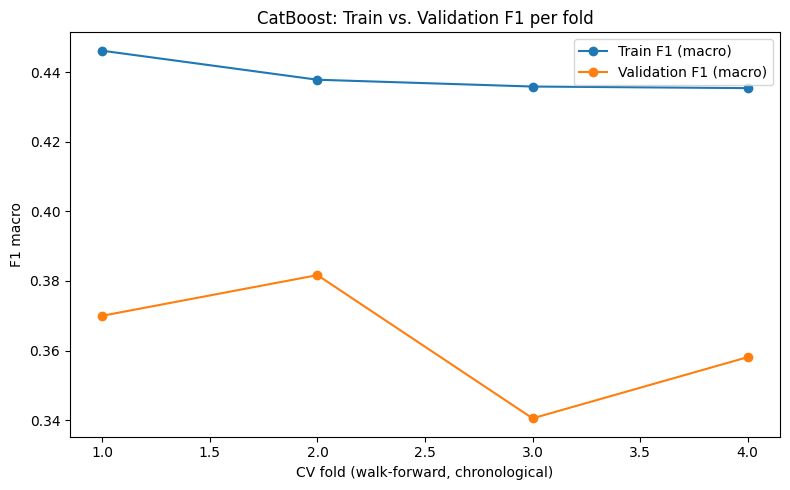

   fold  train_f1_macro  val_f1_macro     gap
0     1          0.4461        0.3700  0.0761
1     2          0.4378        0.3817  0.0561
2     3          0.4358        0.3406  0.0953
3     4          0.4354        0.3581  0.0772

Mean overfit gap (train F1 - val F1): 0.0762


In [16]:
# Retrain the tuned model on each CV fold to inspect the per-fold gap.
final_cv_train, final_cv_val = [], []
for ft, fv in cv_folds:
    fold_pre = fit_preprocessing(ft, selected_features)
    Xt, Xv = fold_pre.transform(ft), fold_pre.transform(fv)
    yt, yv = ft[TARGET_COL], fv[TARGET_COL]

    model = build_models()[best_model_name]
    model.set_params(**best_params)
    model = fit_with_early_stopping(best_model_name, model, Xt, yt)

    final_cv_train.append(evaluate(model, Xt, yt))
    final_cv_val.append(evaluate(model, Xv, yv))

gap_df = pd.DataFrame({
    "fold": range(1, len(cv_folds) + 1),
    "train_f1_macro": [r["f1_macro"] for r in final_cv_train],
    "val_f1_macro": [r["f1_macro"] for r in final_cv_val],
})
gap_df["gap"] = gap_df["train_f1_macro"] - gap_df["val_f1_macro"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gap_df["fold"], gap_df["train_f1_macro"], marker="o", label="Train F1 (macro)")
ax.plot(gap_df["fold"], gap_df["val_f1_macro"], marker="o", label="Validation F1 (macro)")
ax.set_xlabel("CV fold (walk-forward, chronological)")
ax.set_ylabel("F1 macro")
ax.set_title(f"{best_model_name}: Train vs. Validation F1 per fold")
ax.legend()
plt.tight_layout()
plt.show()

print(gap_df.round(4))
print(f"\nMean overfit gap (train F1 - val F1): {gap_df['gap'].mean():.4f}")


## 13. Final Held-Out Test Evaluation

The test set has **never been touched** by feature selection,
preprocessing fitting, model comparison, or hyperparameter tuning — it
is scored exactly once, here, with the final chosen configuration
retrained on Train+Validation. This is the only number in the
notebook that should be treated as an honest estimate of
out-of-sample performance.


── Final Test Metrics (regression-style summary) ──
  accuracy          : 0.4196
  f1_macro          : 0.3787
  precision_macro   : 0.3810
  recall_macro      : 0.3812
  roc_auc_ovr       : 0.5564

Train vs Test F1 macro gap: 0.0521

              precision    recall  f1-score   support

  Neutral(0)       0.60      0.51      0.55      1317
       Up(1)       0.27      0.29      0.28       570
     Down(2)       0.28      0.35      0.31       613

    accuracy                           0.42      2500
   macro avg       0.38      0.38      0.38      2500
weighted avg       0.44      0.42      0.43      2500



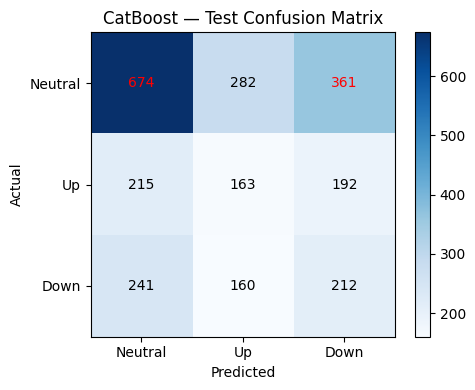

In [17]:
# Refit preprocessing + final model on Train+Validation, evaluate once on Test.
train_val_df = pd.concat([train_df, val_df]).sort_values(["stock", "Date"])
final_pre = fit_preprocessing(train_val_df, selected_features)

X_trval = final_pre.transform(train_val_df)
y_trval = train_val_df[TARGET_COL]
X_test_final = final_pre.transform(test_df)
y_test_final = test_df[TARGET_COL]

final_model = build_models()[best_model_name]
final_model.set_params(**best_params)
final_model = fit_with_early_stopping(best_model_name, final_model, X_trval, y_trval)

test_metrics = evaluate(final_model, X_test_final, y_test_final)
train_metrics_final = evaluate(final_model, X_trval, y_trval)

print("── Final Test Metrics (regression-style summary) ──")
for k, v in test_metrics.items():
    print(f"  {k:18s}: {v:.4f}")

print(f"\nTrain vs Test F1 macro gap: {train_metrics_final['f1_macro'] - test_metrics['f1_macro']:.4f}")

preds_test = final_model.predict(X_test_final)
print("\n" + classification_report(y_test_final, preds_test,
      target_names=["Neutral(0)", "Up(1)", "Down(2)"], zero_division=0))

cm = confusion_matrix(y_test_final, preds_test)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(["Neutral", "Up", "Down"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Neutral", "Up", "Down"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{best_model_name} — Test Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="Red" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 14. Feature Importance (Native / Permutation / SHAP)

Three lenses, since each has known blind spots: native impurity/gain
importance can overrate high-cardinality numeric features, permutation
importance is model-agnostic but slower, and SHAP gives per-prediction
attribution and captures interactions the other two miss. All three
are computed on the **test set predictions** (or its held-back
portion) so importance reflects genuine out-of-sample behavior, not
memorized training patterns.


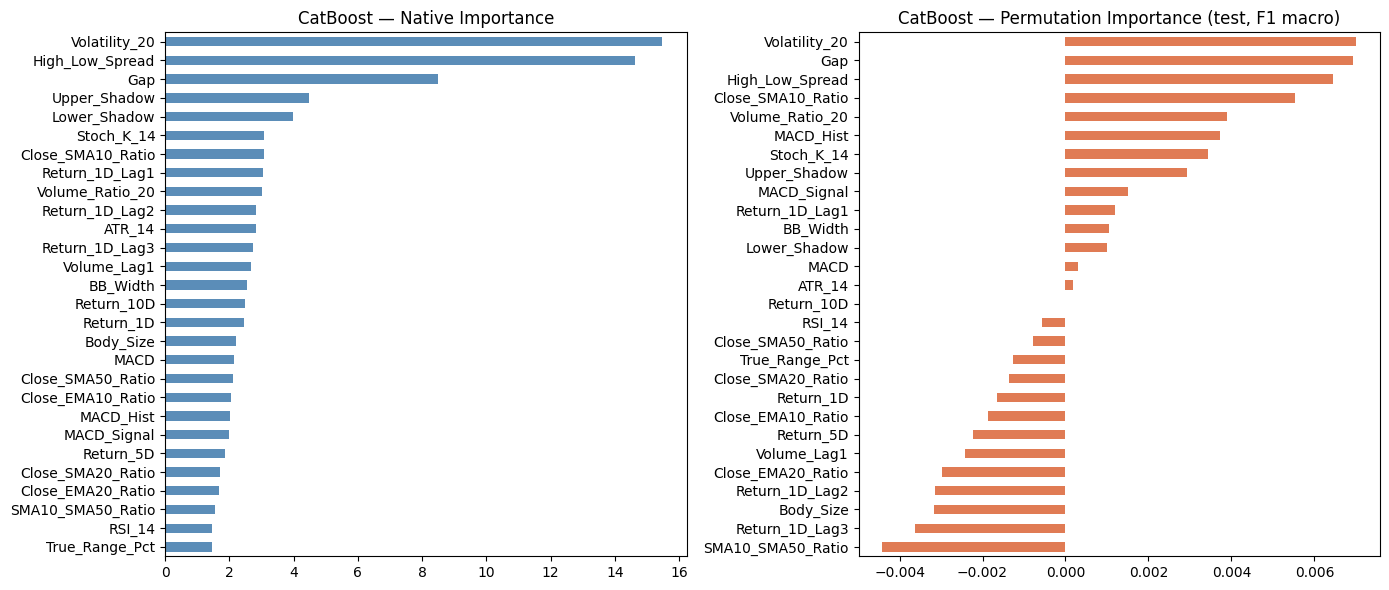

In [18]:
from sklearn.inspection import permutation_importance

native_importance = pd.Series(
    getattr(final_model, "feature_importances_", None),
    index=selected_features
).sort_values(ascending=False) if hasattr(final_model, "feature_importances_") else None

perm = permutation_importance(final_model, X_test_final, y_test_final,
                               n_repeats=10, random_state=RANDOM_STATE, scoring="f1_macro")
perm_importance = pd.Series(perm.importances_mean, index=selected_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if native_importance is not None:
    native_importance.plot.barh(ax=axes[0], color="#5B8DB8")
    axes[0].invert_yaxis()
    axes[0].set_title(f"{best_model_name} — Native Importance")
perm_importance.plot.barh(ax=axes[1], color="#E07B54")
axes[1].invert_yaxis()
axes[1].set_title(f"{best_model_name} — Permutation Importance (test, F1 macro)")
plt.tight_layout()
plt.show()


['Return_1D', 'Return_1D_Lag1', 'Return_1D_Lag2', 'Close_SMA10_Ratio', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'Close_EMA10_Ratio', 'RSI_14', 'MACD', 'MACD_Hist', 'Stoch_K_14', 'Volatility_20', 'ATR_14', 'True_Range_Pct', 'BB_Width', 'Volume_Ratio_20', 'Volume_Lag1', 'High_Low_Spread', 'Upper_Shadow', 'Lower_Shadow']
20
{'accuracy': 0.4216, 'f1_macro': 0.3827593504664573, 'precision_macro': 0.38392040254905796, 'recall_macro': 0.3857632880957785, 'roc_auc_ovr': np.float64(0.5560283848407486)}
── Final Test Metrics (regression-style summary) ──
  accuracy          : 0.4196
  f1_macro          : 0.3787
  precision_macro   : 0.3810
  recall_macro      : 0.3812
  roc_auc_ovr       : 0.5564

Train vs Test F1 macro gap: 0.0420

              precision    recall  f1-score   support

  Neutral(0)       0.59      0.51      0.55      1317
       Up(1)       0.29      0.34      0.31       570
     Down(2)       0.27      0.31      0.29       613

    accuracy                           0.42     

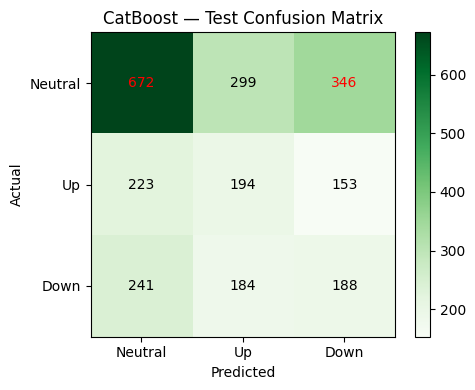

In [19]:
drop_features = [
    "Gap",
    "Return_5D",
    "Body_Size",
    "SMA10_SMA50_Ratio",
    "Return_10D",
    "Close_EMA20_Ratio",
    "Return_1D_Lag3",
    "MACD_Signal"
]


select_features = [
    f for f in selected_features
    if f not in drop_features
]

print(select_features)
print(len(select_features))

train_val_df = pd.concat([train_df, val_df]).sort_values(["stock", "Date"])

final_preprocessing = fit_preprocessing(
    train_val_df,
    select_features
)

X_trval_last = final_preprocessing.transform(train_val_df)
X_test_last = final_preprocessing.transform(test_df)

y_trval = train_val_df[TARGET_COL]
y_test_final = test_df[TARGET_COL]
final_model = build_models()[best_model_name]
final_model.set_params(**best_params)

final_model_cat = fit_with_early_stopping(
    best_model_name,
    final_model,
    X_trval_last,
    y_trval
)

test_metrics_final = evaluate(final_model_cat, X_test_last, y_test_final)
print(test_metrics_final)

train_metrics_final = evaluate(final_model_cat, X_trval_last, y_trval)

print("── Final Test Metrics (regression-style summary) ──")
for k, v in test_metrics.items():
    print(f"  {k:18s}: {v:.4f}")

print(f"\nTrain vs Test F1 macro gap: {train_metrics_final['f1_macro'] - test_metrics_final['f1_macro']:.4f}")

preds_test = final_model_cat.predict(X_test_final)
print("\n" + classification_report(y_test_final, preds_test,
      target_names=["Neutral(0)", "Up(1)", "Down(2)"], zero_division=0))

cm = confusion_matrix(y_test_final, preds_test)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(3)); ax.set_xticklabels(["Neutral", "Up", "Down"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Neutral", "Up", "Down"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{best_model_name} — Test Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="Red" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

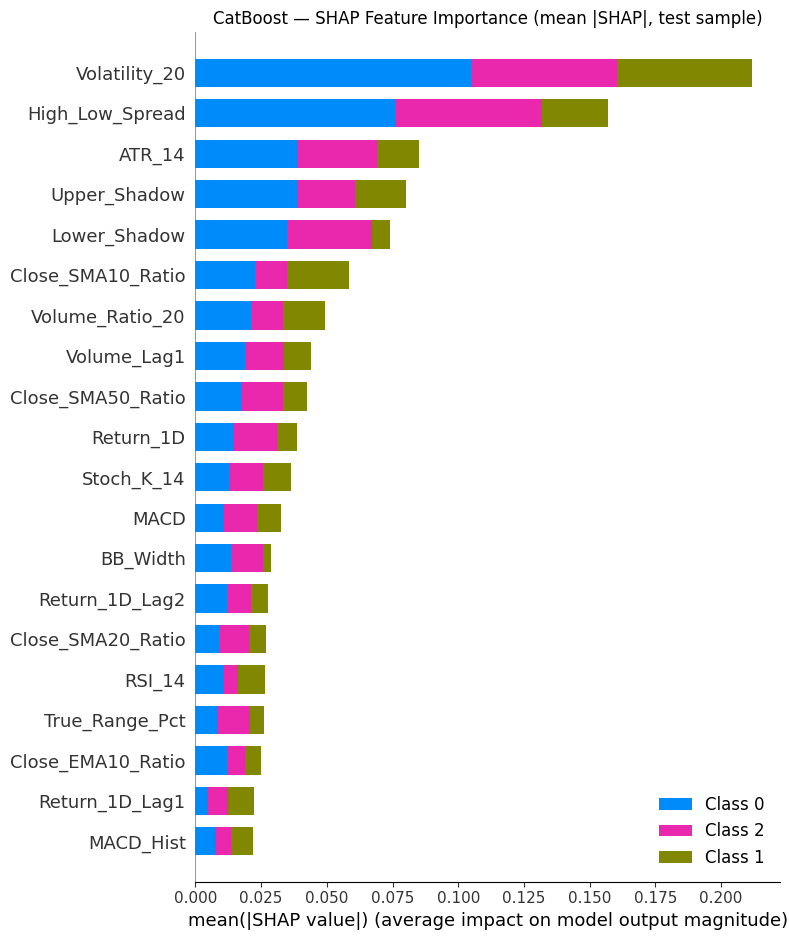

In [20]:
import shap

sample = X_test_last.sample(min(500, len(X_test_last)), random_state=RANDOM_STATE)
try:
    explainer = shap.TreeExplainer(final_model_cat)
    shap_values = explainer.shap_values(sample)
    shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
    plt.title(f"{best_model_name} — SHAP Feature Importance (mean |SHAP|, test sample)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP explanation skipped ({e}); native + permutation importance above still apply.")
